# eNose Methane — ทำนาย ppm ด้วย Regression

Notebook นี้ใช้สำหรับ:
1. **Feature extraction** จาก CSV ที่ประมวลผลแล้ว (ADC + BME280) ตาม convention ΔV ของ eNose
2. **Feature selection** ด้วย correlation กับ ppm (เลือก top-k)
3. **Train Linear Regression** เป็นหลัก + เปรียบเทียบ regressor อื่นๆ
4. **บันทึกโมเดล** และทำนาย ppm จาก run ใหม่

## การออกแบบการเก็บข้อมูล

| พารามิเตอร์ | ค่า |
|---|---|
| อุณหภูมิ (heater setpoint) | 50, 40, 30 °C |
| ความเข้มข้นมีเทน | 1, 1.5, 5, 10 ppm |
| ทำซ้ำต่อเงื่อนไข | 3–5 ครั้ง |

## โครงสร้างโฟลเดอร์ข้อมูล

```
testdata/
├── 50_1ppm_28.5/
│   ├── adc1263_YYYYMMDD_HHMMSS.csv
│   └── bme280_YYYYMMDD_HHMMSS.csv
├── 40_5ppm_28.5/
│   └── ...
└── ...
```

## Pipeline

```
Google Drive → scan folders → extract ΔV/slope/BME → QC → EDA
  → feature selection → GroupKFold CV → Linear Regression
  → compare regressors → save model → inference
```

In [ ]:
# ติดตั้งแพ็กเกจ (Colab มี scikit-learn อยู่แล้ว แต่ติดตั้งเพิ่มเพื่อความแน่ใจ)
!pip install -q scikit-learn scipy seaborn joblib

In [ ]:
import json
import re
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import (
    ElasticNetCV,
    LassoCV,
    LinearRegression,
    RidgeCV,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    GroupKFold,
    LeaveOneGroupOut,
    cross_val_predict,
    cross_validate,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

print("Imports OK")

Imports OK


In [ ]:
# ── Config ──────────────────────────────────────────────────────────────────
# แก้ path ให้ตรงกับโฟลเดอร์ testdata บน Google Drive ของคุณ

DATA_DIR = Path("/content/drive/MyDrive/eNose/testdata")
OUTPUT_DIR = Path("/content/drive/MyDrive/eNose/models")

# หน้าต่างวิเคราะห์ (วินาที, inclusive) — สอดคล้อง hardware_config + enose-delta-v
ANALYSIS_WINDOWS = {
    "baseline": (250, 300),
    "measure": (305, 365),
}

SENSORS = ["ss1", "ss2", "ss3", "ss4"]
# ΔV: ss1/ss2 ใช้ Vmin−baseline, ss3/ss4 ใช้ Vmax−baseline
DV_MIN_SENSORS = {"ss1", "ss2"}
DV_MAX_SENSORS = {"ss3", "ss4"}
TARGET = "methane_ppm"

# Feature flags
INCLUDE_BME = True          # T_baseline, Humid_baseline, T_measure, Humid_measure, pressure_mean
INCLUDE_TEMP_SET = False     # ใส่ temp_set (heater setpoint) เป็น feature

MIN_SAMPLES = 10            # QC: จำนวน sample ขั้นต่ำต่อ window
REQUIRE_QC = True           # กรองเฉพาะ run ที่ผ่าน QC
N_CV_FOLDS = 5              # GroupKFold folds (ปรับตามจำนวน group)
N_SELECT_FEATURES = 8       # จำนวน feature ที่เลือกจาก |correlation| กับ ppm สูงสุด
RANDOM_STATE = 42

# ── Manual feature selection ─────────────────────────────────────────────────
# ตั้ง MANUAL_FEATURES = None  → ใช้ correlation top-k อัตโนมัติ
# ตั้ง MANUAL_FEATURES = [...]  → ใช้ list ที่กำหนดเอง (ข้าม auto selection)
#
# Feature ที่มีทั้งหมด:
#   Sensor : dV_ss1..4, dVmax_ss1..4, slope_ss1..4, ratio_ss1..4, hybrid_ss1..4
#   BME    : T_baseline, Humid_baseline, T_measure, Humid_measure, pressure_mean
#   Meta   : temp_set
MANUAL_FEATURES: Optional[List[str]] = ['dVmax_ss4', 'dVmax_ss3', 'T_baseline', 'T_measure']
# ตัวอย่างถ้าอยากเลือกเอง:
# MANUAL_FEATURES = ["dV_ss1", "dV_ss2", "dV_ss3", "dV_ss4", "temp_set"]

# ชื่อ feature มาตรฐาน (25 คอลัมน์)
DV_FEATURES = [f"dV_{s}" for s in SENSORS]
DVMAX_FEATURES = [f"dVmax_{s}" for s in SENSORS]
SLOPE_FEATURES = [f"slope_{s}" for s in SENSORS]
RATIO_FEATURES = [f"ratio_{s}" for s in SENSORS]    # dVmax / avg(baseline)
HYBRID_FEATURES = [f"hybrid_{s}" for s in SENSORS]  # (dVmax - avg(baseline)) / avg(baseline)
BME_BASELINE_FEATURES = ["T_baseline", "Humid_baseline"]
BME_MEASURE_FEATURES = ["T_measure", "Humid_measure", "pressure_mean"]
BME_FEATURES = BME_BASELINE_FEATURES + BME_MEASURE_FEATURES
SENSOR_FEATURES = DV_FEATURES + DVMAX_FEATURES + SLOPE_FEATURES + RATIO_FEATURES + HYBRID_FEATURES
ALL_EXTRACTED_FEATURES = SENSOR_FEATURES + BME_FEATURES

# สำหรับจัดกลุ่มสีในกราฟ EDA / feature selection
FEATURE_GROUPS = {
    "ΔV": DV_FEATURES,
    "dVmax": DVMAX_FEATURES,
    "slope": SLOPE_FEATURES,
    "ratio": RATIO_FEATURES,
    "hybrid": HYBRID_FEATURES,
    "BME": BME_FEATURES,
}
FEATURE_GROUP_COLORS = {
    "ΔV": "#4C72B0",
    "dVmax": "#55A868",
    "slope": "#C44E52",
    "ratio": "#8172B2",
    "hybrid": "#CCB974",
    "BME": "#64B5CD",
    "meta": "#888888",
}


def get_feature_group(feature: str) -> str:
    """คืนชื่อกลุ่ม feature สำหรับใช้จัดสี/แสดงผล."""
    for group, feats in FEATURE_GROUPS.items():
        if feature in feats:
            return group
    if feature == "temp_set":
        return "meta"
    return "other"


print(f"DATA_DIR   = {DATA_DIR}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")
print(f"Features   = {len(ALL_EXTRACTED_FEATURES)} extracted + flags")

DATA_DIR   = /content/drive/MyDrive/eNose/testdata
OUTPUT_DIR = /content/drive/MyDrive/eNose/models
Features   = 17 extracted + flags


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Drive mounted. Output → {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Output → /content/drive/MyDrive/eNose/models


## 1. Manifest — สแกนโฟลเดอร์และจับคู่ไฟล์

แต่ละโฟลเดอร์ย่อย = 1 condition (temp + ppm)
ภายในโฟลเดอร์มีหลายไฟล์ CSV (1 ไฟล์ = 1 repeat)
จับคู่ `adc1263_*.csv` กับ `bme280_*.csv` ที่ timestamp ใกล้กันที่สุด

In [ ]:
def parse_folder_meta(folder_name: str) -> Dict[str, Any]:
    """แยก temp_set และ methane_ppm จากชื่อโฟลเดอร์.

    รูปแบบใหม่: 50_1ppm_28.5  → temp_set=50, methane_ppm=1.0
    รูปแบบ legacy: 5ppm       → temp_set=None, methane_ppm=5.0
    """
    name = folder_name.strip()

    # รูปแบบใหม่: <temp>_<ppm>ppm_<ambient>
    m = re.match(r"^(\d+)_(\d+(?:\.\d+)?)ppm", name, re.IGNORECASE)
    if m:
        return {
            "temp_set": int(m.group(1)),
            "methane_ppm": float(m.group(2)),
        }

    # รูปแบบ legacy: <ppm>ppm
    m = re.match(r"^(\d+(?:\.\d+)?)ppm$", name, re.IGNORECASE)
    if m:
        return {
            "temp_set": None,
            "methane_ppm": float(m.group(1)),
        }

    raise ValueError(f"ไม่รู้จักรูปแบบชื่อโฟลเดอร์: {folder_name!r}")


def _latest_file(folder: Path, prefix: str) -> Optional[Path]:
    """เลือกไฟล์ล่าสุดตามชื่อ (timestamp ในชื่อไฟล์) — ใช้สำหรับ inference."""
    files = sorted(folder.glob(f"{prefix}_*.csv"))
    return files[-1] if files else None


def _file_ts(path: Path) -> int:
    """แปลง timestamp จากชื่อไฟล์ (YYYYMMDD_HHMMSS) เป็นตัวเลข เพื่อเปรียบเทียบ."""
    # ชื่อไฟล์: adc1263_20260528_180038.csv → stem = adc1263_20260528_180038
    parts = path.stem.split("_")
    # parts[-2] = YYYYMMDD, parts[-1] = HHMMSS
    if len(parts) >= 2:
        try:
            return int(parts[-2] + parts[-1])
        except ValueError:
            pass
    return 0


def _match_bme(adc_file: Path, bme_files: List[Path]) -> Optional[Path]:
    """หา bme280 ที่ timestamp ใกล้กับ adc มากที่สุด."""
    if not bme_files:
        return None
    adc_ts = _file_ts(adc_file)
    return min(bme_files, key=lambda f: abs(_file_ts(f) - adc_ts))


def build_manifest(data_dir: Path) -> pd.DataFrame:
    """สแกนโฟลเดอร์ วนทุกไฟล์ adc → จับคู่ bme → สร้าง manifest ของทุก run."""
    rows: List[Dict[str, Any]] = []

    for folder in sorted(data_dir.iterdir()):
        if not folder.is_dir():
            continue
        try:
            meta = parse_folder_meta(folder.name)
        except ValueError as exc:
            print(f"[skip] {folder.name}: {exc}")
            continue

        adc_files = sorted(folder.glob("adc1263_*.csv"))
        bme_files = sorted(folder.glob("bme280_*.csv"))

        if not adc_files:
            print(f"[skip] {folder.name}: ไม่พบ adc1263_*.csv")
            continue

        for adc_file in adc_files:
            bme_file = _match_bme(adc_file, bme_files)
            rows.append({
                "folder": folder.name,
                "folder_path": str(folder),
                "adc_csv": str(adc_file),
                "bme_csv": str(bme_file) if bme_file else None,
                "temp_set": meta["temp_set"],
                "methane_ppm": meta["methane_ppm"],
            })

    if not rows:
        raise FileNotFoundError(f"ไม่พบ run ใน {data_dir}")

    df = pd.DataFrame(rows)

    # ไล่หมายเลข repeat ต่อกลุ่ม (temp_set, methane_ppm) เรียงตาม adc_csv
    df = df.sort_values(["temp_set", "methane_ppm", "adc_csv"]).reset_index(drop=True)
    df["repeat"] = df.groupby(["temp_set", "methane_ppm"], dropna=False).cumcount() + 1
    df["group_id"] = (
        df["temp_set"].astype(str) + "_" + df["methane_ppm"].astype(str) + "_" + df["repeat"].astype(str)
    )

    return df


manifest = build_manifest(DATA_DIR)
print(f"พบ {len(manifest)} runs")
print(manifest.groupby(["temp_set", "methane_ppm"]).size().unstack(fill_value=0))
manifest.head(10)

พบ 44 runs
methane_ppm  1.0   1.5   5.0   10.0
temp_set                           
30              3     3     3     3
40              3     3     3     3
50              5     5     5     5


,folder,folder_path,adc_csv,bme_csv,temp_set,methane_ppm,repeat,group_id
0,30_1ppm_28.5,/content/drive/MyDrive/eNose/testdata/30_1ppm_...,/content/drive/MyDrive/eNose/testdata/30_1ppm_...,/content/drive/MyDrive/eNose/testdata/30_1ppm_...,30,1.0,1,30_1.0_1
1,30_1ppm_28.5,/content/drive/MyDrive/eNose/testdata/30_1ppm_...,/content/drive/MyDrive/eNose/testdata/30_1ppm_...,/content/drive/MyDrive/eNose/testdata/30_1ppm_...,30,1.0,2,30_1.0_2
2,30_1ppm_28.5,/content/drive/MyDrive/eNose/testdata/30_1ppm_...,/content/drive/MyDrive/eNose/testdata/30_1ppm_...,/content/drive/MyDrive/eNose/testdata/30_1ppm_...,30,1.0,3,30_1.0_3
3,30_1.5ppm_28.5,/content/drive/MyDrive/eNose/testdata/30_1.5pp...,/content/drive/MyDrive/eNose/testdata/30_1.5pp...,/content/drive/MyDrive/eNose/testdata/30_1.5pp...,30,1.5,1,30_1.5_1
4,30_1.5ppm_28.5,/content/drive/MyDrive/eNose/testdata/30_1.5pp...,/content/drive/MyDrive/eNose/testdata/30_1.5pp...,/content/drive/MyDrive/eNose/testdata/30_1.5pp...,30,1.5,2,30_1.5_2
5,30_1.5ppm_28.5,/content/drive/MyDrive/eNose/testdata/30_1.5pp...,/content/drive/MyDrive/eNose/testdata/30_1.5pp...,/content/drive/MyDrive/eNose/testdata/30_1.5pp...,30,1.5,3,30_1.5_3
6,30_5ppm_28.5,/content/drive/MyDrive/eNose/testdata/30_5ppm_...,/content/drive/MyDrive/eNose/testdata/30_5ppm_...,/content/drive/MyDrive/eNose/testdata/30_5ppm_...,30,5.0,1,30_5.0_1
7,30_5ppm_28.5,/content/drive/MyDrive/eNose/testdata/30_5ppm_...,/content/drive/MyDrive/eNose/testdata/30_5ppm_...,/content/drive/MyDrive/eNose/testdata/30_5ppm_...,30,5.0,2,30_5.0_2
8,30_5ppm_28.5,/content/drive/MyDrive/eNose/testdata/30_5ppm_...,/content/drive/MyDrive/eNose/testdata/30_5ppm_...,/content/drive/MyDrive/eNose/testdata/30_5ppm_...,30,5.0,3,30_5.0_3
9,30_10ppm_28.5,/content/drive/MyDrive/eNose/testdata/30_10ppm...,/content/drive/MyDrive/eNose/testdata/30_10ppm...,/content/drive/MyDrive/eNose/testdata/30_10ppm...,30,10.0,1,30_10.0_1


## 2. Feature Extraction (ΔV / slope / ratio / hybrid / BME)

สูตรมาตรฐาน eNose ΔV:
- `dV_ss1`, `dV_ss2` = **min(measure)** − **avg(baseline)** (Vmin − Baseline)
- `dV_ss3`, `dV_ss4` = **max(measure)** − **avg(baseline)** (Vmax − Baseline)
- `dVmax_ssN` = **max(measure)** − **avg(baseline)** (ทุกเซ็นเซอร์)
- `slope_ssN` = **(max − min) / (t_max − t_min)** ในหน้าต่าง measure
- `ratio_ssN` = **ΔVmax / avg(baseline)** — normalize ΔVmax ด้วยระดับ baseline ของแต่ละ run
- `hybrid_ssN` = **(ΔVmax − avg(baseline)) / avg(baseline)**
- BME: mean ใน baseline/measure window

> หมายเหตุ: `hybrid_ssN = ratio_ssN − 1` เสมอ (ต่างกันแค่ค่าคงที่)
> หลังผ่าน StandardScaler ทั้งสองจะกลายเป็น feature เดียวกัน — ควรเลือกใช้แค่ตัวใดตัวหนึ่งในโมเดล

In [ ]:
def slice_window(df: pd.DataFrame, lo: float, hi: float) -> pd.DataFrame:
    """ตัดข้อมูลตาม elapsed_time_sec (inclusive)."""
    t = df["elapsed_time_sec"]
    return df.loc[(t >= lo) & (t <= hi)].copy()


def _nanmean(series: pd.Series) -> float:
    vals = series.dropna()
    return float(vals.mean()) if len(vals) > 0 else np.nan


def compute_sensor_delta_v(
    adc_df: pd.DataFrame,
    windows: Dict[str, Tuple[float, float]] = ANALYSIS_WINDOWS,
) -> Dict[str, float]:
    """คำนวณ dV, dVmax, ratio, hybrid สำหรับทุกเซ็นเซอร์."""
    bl = slice_window(adc_df, *windows["baseline"])
    ms = slice_window(adc_df, *windows["measure"])
    out: Dict[str, float] = {}

    for sensor in SENSORS:
        col = f"{sensor}_lp_ma"
        bl_avg = _nanmean(bl[col]) if col in bl.columns else np.nan
        if col not in ms.columns or not np.isfinite(bl_avg):
            out[f"dV_{sensor}"] = np.nan
            out[f"dVmax_{sensor}"] = np.nan
            out[f"ratio_{sensor}"] = np.nan
            out[f"hybrid_{sensor}"] = np.nan
            continue
        ms_vals = ms[col].dropna()
        if len(ms_vals) == 0:
            out[f"dV_{sensor}"] = np.nan
            out[f"dVmax_{sensor}"] = np.nan
            out[f"ratio_{sensor}"] = np.nan
            out[f"hybrid_{sensor}"] = np.nan
        else:
            v_min = float(ms_vals.min())
            v_max = float(ms_vals.max())
            dv_max = v_max - bl_avg
            if sensor in DV_MAX_SENSORS:
                out[f"dV_{sensor}"] = dv_max
            else:
                out[f"dV_{sensor}"] = v_min - bl_avg
            out[f"dVmax_{sensor}"] = dv_max
            if bl_avg != 0:
                out[f"ratio_{sensor}"] = dv_max / bl_avg
                out[f"hybrid_{sensor}"] = (dv_max - bl_avg) / bl_avg
            else:
                out[f"ratio_{sensor}"] = np.nan
                out[f"hybrid_{sensor}"] = np.nan
    return out


def compute_sensor_slope(
    adc_df: pd.DataFrame,
    windows: Dict[str, Tuple[float, float]] = ANALYSIS_WINDOWS,
) -> Dict[str, float]:
    """คำนวณ slope ในหน้าต่าง measure."""
    ms = slice_window(adc_df, *windows["measure"])
    out: Dict[str, float] = {}

    for sensor in SENSORS:
        col = f"{sensor}_lp_ma"
        out[f"slope_{sensor}"] = np.nan
        if col not in ms.columns or ms.empty:
            continue
        sub = ms[["elapsed_time_sec", col]].dropna()
        if sub.empty:
            continue
        idx_min = sub[col].idxmin()
        idx_max = sub[col].idxmax()
        v_min, v_max = sub.loc[idx_min, col], sub.loc[idx_max, col]
        t_min, t_max = sub.loc[idx_min, "elapsed_time_sec"], sub.loc[idx_max, "elapsed_time_sec"]
        if t_max == t_min:
            continue
        out[f"slope_{sensor}"] = float((v_max - v_min) / (t_max - t_min))
    return out


def compute_bme_features(
    bme_df: pd.DataFrame,
    windows: Dict[str, Tuple[float, float]] = ANALYSIS_WINDOWS,
) -> Dict[str, float]:
    """คำนวณ BME means ต่อ window."""
    bl = slice_window(bme_df, *windows["baseline"])
    ms = slice_window(bme_df, *windows["measure"])

    col_map = {
        "T_baseline": ("temperature_c_lp_ma", bl),
        "Humid_baseline": ("humidity_pct_lp_ma", bl),
        "T_measure": ("temperature_c_lp_ma", ms),
        "Humid_measure": ("humidity_pct_lp_ma", ms),
        "pressure_mean": ("pressure_hpa_lp_ma", ms),
    }
    out: Dict[str, float] = {}
    for feat, (col, win_df) in col_map.items():
        out[feat] = _nanmean(win_df[col]) if col in win_df.columns else np.nan
    return out


def check_qc(
    adc_df: pd.DataFrame,
    bme_df: Optional[pd.DataFrame],
    features: Dict[str, float],
    min_samples: int = MIN_SAMPLES,
) -> Tuple[bool, Dict[str, Any]]:
    """ตรวจ QC: จำนวน sample + ค่า finite."""
    bl_adc = slice_window(adc_df, *ANALYSIS_WINDOWS["baseline"])
    ms_adc = slice_window(adc_df, *ANALYSIS_WINDOWS["measure"])
    n_adc_bl = len(bl_adc)
    n_adc_ms = len(ms_adc)

    n_bme_bl = n_bme_ms = 0
    if bme_df is not None and not bme_df.empty:
        n_bme_bl = len(slice_window(bme_df, *ANALYSIS_WINDOWS["baseline"]))
        n_bme_ms = len(slice_window(bme_df, *ANALYSIS_WINDOWS["measure"]))

    dv_slope_keys = DV_FEATURES + DVMAX_FEATURES + SLOPE_FEATURES
    dv_slope_ok = all(np.isfinite(features.get(k, np.nan)) for k in dv_slope_keys)

    qc_pass = (
        n_adc_bl >= min_samples
        and n_adc_ms >= min_samples
        and dv_slope_ok
    )

    info = {
        "n_adc_baseline": n_adc_bl,
        "n_adc_measure": n_adc_ms,
        "n_bme_baseline": n_bme_bl,
        "n_bme_measure": n_bme_ms,
        "qc_pass": qc_pass,
    }
    return qc_pass, info


def extract_run(
    adc_csv: str,
    bme_csv: Optional[str],
    meta: Dict[str, Any],
) -> Dict[str, Any]:
    """Extract features จาก 1 run → 1 แถว."""
    adc_df = pd.read_csv(adc_csv)
    bme_df = pd.read_csv(bme_csv) if bme_csv and Path(bme_csv).exists() else None

    features: Dict[str, Any] = {}
    features.update(compute_sensor_delta_v(adc_df))
    features.update(compute_sensor_slope(adc_df))
    if bme_df is not None:
        features.update(compute_bme_features(bme_df))
    else:
        for f in BME_FEATURES:
            features[f] = np.nan

    qc_pass, qc_info = check_qc(adc_df, bme_df, features)

    row = {**meta, **features, **qc_info}
    return row


print("Feature extraction functions ready")

def predict_ppm_pi_style(
    feat_row: Dict[str, Any],
    selected: List[str],
    pipeline,
) -> Optional[float]:
    """ทำนายแบบเดียวกับ predict_methane.py บน Pi — ไม่ fill NaN."""
    feat_vals = {k: feat_row.get(k, np.nan) for k in selected}
    X = pd.DataFrame([feat_vals])[selected]
    missing = [c for c in selected if not np.isfinite(X[c].iloc[0])]
    if missing:
        print(f"[predict] ข้ามการทำนาย — feature ไม่ครบ: {missing}")
        return None
    ppm = float(pipeline.predict(X)[0])
    print(f"[predict] ทำนาย: {ppm:.3f} ppm")
    return ppm


Feature extraction functions ready


In [ ]:
def build_curated_dataset(manifest_df: pd.DataFrame) -> pd.DataFrame:
    """วนทุก run ใน manifest แล้วรวมเป็น curated DataFrame."""
    rows = []
    for _, run in manifest_df.iterrows():
        meta = {
            "folder": run["folder"],
            "temp_set": run["temp_set"],
            "methane_ppm": run["methane_ppm"],
            "repeat": run["repeat"],
            "group_id": run["group_id"],
        }
        try:
            row = extract_run(run["adc_csv"], run["bme_csv"], meta)
            rows.append(row)
        except Exception as exc:
            print(f"[error] {run['folder']}: {exc}")

    curated = pd.DataFrame(rows)
    return curated


curated_df = build_curated_dataset(manifest)

# กรอง QC
if REQUIRE_QC:
    n_before = len(curated_df)
    curated_df = curated_df[curated_df["qc_pass"]].copy()
    print(f"QC filter: {n_before} → {len(curated_df)} runs")

# บันทึก curated.csv
curated_path = OUTPUT_DIR / "curated.csv"
curated_df.to_csv(curated_path, index=False)
print(f"บันทึก → {curated_path}")

# สรุปจำนวน run ต่อ (temp_set, ppm)
print("\nจำนวน run ต่อ (temp_set, ppm):")
print(curated_df.groupby(["temp_set", "methane_ppm"]).size().unstack(fill_value=0))

print(f"\nExtracted feature columns ({len(ALL_EXTRACTED_FEATURES)}):")
for grp, feats in FEATURE_GROUPS.items():
    print(f"  {grp:6s}: {', '.join(feats)}")

display(curated_df[ALL_EXTRACTED_FEATURES + ["methane_ppm", "temp_set", "qc_pass"]].head())

## 3. EDA — สำรวจข้อมูล

In [ ]:
def get_model_features(
    include_bme: bool = INCLUDE_BME,
    include_temp_set: bool = INCLUDE_TEMP_SET,
) -> List[str]:
    """รายชื่อ feature ที่ใช้ train ตาม config flags."""
    feats = list(SENSOR_FEATURES)
    if include_bme:
        feats += BME_FEATURES
    if include_temp_set:
        feats.append("temp_set")
    return feats


MODEL_FEATURES = get_model_features()
print(f"Model features ({len(MODEL_FEATURES)}): {MODEL_FEATURES}")

# สถิติเชิงพรรณนา — แยกกลุ่ม sensor / BME
stats_df = curated_df[MODEL_FEATURES + [TARGET]].describe().T
stats_df["group"] = [get_feature_group(f) if f != TARGET else "target" for f in stats_df.index]
display(stats_df)

for group_name, group_feats in FEATURE_GROUPS.items():
    cols = [c for c in group_feats if c in curated_df.columns]
    if cols:
        print(f"\n=== {group_name} ({len(cols)} features) ===")
        display(curated_df[cols].describe().T)

# Correlation กับ ppm ทุก feature (เรียงตาม |r|)
corr_with_target = (
    curated_df[MODEL_FEATURES]
    .corrwith(curated_df[TARGET])
    .rename("corr")
    .to_frame()
)
corr_with_target["abs_corr"] = corr_with_target["corr"].abs()
corr_with_target["group"] = [get_feature_group(f) for f in corr_with_target.index]
corr_with_target = corr_with_target.sort_values("abs_corr", ascending=False)
print("\n=== |Correlation| กับ methane_ppm (ทุก feature) ===")
display(corr_with_target.reset_index().rename(columns={"index": "feature"}))

# Bar chart |corr| ทุก feature — สีตามกลุ่ม
fig, ax = plt.subplots(figsize=(11, 9))
plot_corr = corr_with_target.sort_values("abs_corr", ascending=True)
colors = [FEATURE_GROUP_COLORS.get(g, "#aaaaaa") for g in plot_corr["group"]]
ax.barh(plot_corr.index, plot_corr["abs_corr"], color=colors)
ax.set_xlabel("|correlation| กับ methane_ppm")
ax.set_title("Feature Correlation Ranking (25 features + BME)")
for grp, color in FEATURE_GROUP_COLORS.items():
    if grp in plot_corr["group"].values:
        ax.barh([], [], color=color, label=grp)
ax.legend(title="กลุ่ม feature", loc="lower right")
plt.tight_layout()
plt.show()

# Correlation heatmap (ขยายขนาดให้ครบ 25+ features)
corr_cols = MODEL_FEATURES + [TARGET]
corr_mat = curated_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation Matrix — Features vs methane_ppm")
plt.tight_layout()
plt.show()

# Scatter: top-3 features (รวม ratio/hybrid ถ้าติดอันดับ)
top_feats = corr_with_target.head(3).index.tolist()
print("Top-3 features:", top_feats)

fig, axes = plt.subplots(1, len(top_feats), figsize=(5 * len(top_feats), 4), sharey=True)
if len(top_feats) == 1:
    axes = [axes]
for ax, feat in zip(axes, top_feats):
    for temp in sorted(curated_df["temp_set"].dropna().unique()):
        sub = curated_df[curated_df["temp_set"] == temp]
        ax.scatter(sub[feat], sub[TARGET], alpha=0.8, edgecolors="k", linewidths=0.5, label=f"{temp}°C")
    ax.set_xlabel(feat)
    ax.set_title(f"{get_feature_group(feat)} | |r|={corr_with_target.loc[feat, 'abs_corr']:.3f}")
axes[0].set_ylabel("methane_ppm")
axes[-1].legend(title="temp_set", fontsize=8)
fig.suptitle("Top features vs ppm", y=1.02)
plt.tight_layout()
plt.show()

# Boxplot ppm ต่อ temp (จำนวน run)
fig, ax = plt.subplots(figsize=(8, 4))
curated_df.boxplot(column=TARGET, by="temp_set", ax=ax)
ax.set_title("การกระจาย ppm ต่อ temp_set")
ax.set_xlabel("temp_set (°C)")
ax.set_ylabel("methane_ppm")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 4. Feature Selection

**2 โหมด** — เลือกได้ใน config (`MANUAL_FEATURES`):

| โหมด | วิธีตั้ง | เหมาะกับ |
|---|---|---|
| **Auto** (correlation top-k) | `MANUAL_FEATURES = None` | ลองครั้งแรก |
| **Manual** (เลือกเอง) | `MANUAL_FEATURES = ["dV_ss3", "ratio_ss4", ...]` | ปรับ feature หลังดู EDA แล้ว |

Feature ที่เลือกได้: `dV`, `dVmax`, `slope`, `ratio`, `hybrid` (×4 sensors) + BME

In [ ]:
def select_features_by_corr(
    X: pd.DataFrame,
    y: pd.Series,
    n_select: int = N_SELECT_FEATURES,
) -> Tuple[List[str], pd.DataFrame]:
    """เลือก feature จาก |correlation| กับ target สูงสุด k ตัว."""
    X_filled = X.fillna(X.median())
    corr = X_filled.corrwith(y).abs().sort_values(ascending=False)
    n_select = min(n_select, len(corr))
    selected = corr.head(n_select).index.tolist()
    summary = corr.reset_index()
    summary.columns = ["feature", "abs_corr"]
    return selected, summary


# เตรียม X, y, groups
X_full = curated_df[MODEL_FEATURES].copy()
y = curated_df[TARGET].copy()
groups = curated_df["group_id"].values

# ── คำนวณ correlation ทุก feature (แสดงเสมอ เพื่อใช้เป็นข้อมูลเลือก feature) ──
X_filled_all = X_full.fillna(X_full.median())
corr_all = X_filled_all.corrwith(y).abs().sort_values(ascending=False)
corr_summary = corr_all.reset_index()
corr_summary.columns = ["feature", "abs_corr"]
corr_summary["group"] = corr_summary["feature"].map(get_feature_group)
corr_summary["corr"] = curated_df[MODEL_FEATURES].corrwith(y).reindex(corr_summary["feature"]).values
print("=== |Correlation| กับ methane_ppm (ทุก feature — รวม ratio/hybrid) ===")
display(corr_summary)

# ── เลือก feature ──
if MANUAL_FEATURES is not None:
    # ตรวจว่า feature ที่กำหนดมีอยู่จริงใน MODEL_FEATURES
    invalid = [f for f in MANUAL_FEATURES if f not in MODEL_FEATURES]
    if invalid:
        raise ValueError(f"ไม่พบ feature เหล่านี้ใน MODEL_FEATURES: {invalid}")
    selected_features = list(MANUAL_FEATURES)
    feature_summary = corr_summary[corr_summary["feature"].isin(selected_features)].copy()
    print(f"\nโหมด: Manual — ใช้ {len(selected_features)} features ที่กำหนดเอง")
else:
    selected_features, feature_summary = select_features_by_corr(X_full, y)
    print(f"\nโหมด: Auto (correlation top-{N_SELECT_FEATURES})")

print(f"Features ที่เลือก: {selected_features}")

# กราฟ |correlation| ทุก feature — highlight ตัวที่เลือก
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

plot_all = corr_summary.sort_values("abs_corr", ascending=True)
colors_all = [
    FEATURE_GROUP_COLORS.get(g, "#aaaaaa") if f not in selected_features else "#FF6B35"
    for f, g in zip(plot_all["feature"], plot_all["group"])
]
axes[0].barh(plot_all["feature"], plot_all["abs_corr"], color=colors_all)
axes[0].set_xlabel("|correlation| กับ methane_ppm")
axes[0].set_title("ทุก feature (สีส้ม = เลือกใช้ใน model)")
axes[0].invert_yaxis()

plot_sel = corr_summary[corr_summary["feature"].isin(selected_features)].sort_values("abs_corr", ascending=True)
colors_sel = [FEATURE_GROUP_COLORS.get(g, "#aaaaaa") for g in plot_sel["group"]]
axes[1].barh(plot_sel["feature"], plot_sel["abs_corr"], color=colors_sel)
for i, (_, row) in enumerate(plot_sel.iterrows()):
    axes[1].text(row["abs_corr"] + 0.01, i, row["group"], va="center", fontsize=9)
axes[1].set_xlabel("|correlation| กับ methane_ppm")
axes[1].set_title(f"Features ที่เลือก ({len(selected_features)})")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Train Linear Regression (โมเดลหลัก)

ใช้ `GroupKFold` เพื่อกัน data leakage ระหว่าง repeat ของเงื่อนไขเดียวกัน
Pipeline: `StandardScaler` → `LinearRegression`

In [ ]:
def make_cv_splitter(groups: np.ndarray, n_folds: int = N_CV_FOLDS):
    """สร้าง CV splitter ตามจำนวน group."""
    n_groups = len(np.unique(groups))
    if n_groups <= 2:
        return LeaveOneGroupOut(), n_groups
    n_splits = min(n_folds, n_groups)
    return GroupKFold(n_splits=n_splits), n_splits


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """คำนวณ RMSE, MAE, R²."""
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def evaluate_model(
    model,
    X: pd.DataFrame,
    y: pd.Series,
    groups: np.ndarray,
    model_name: str = "model",
) -> Dict[str, Any]:
    """Cross-validate และคืน metrics + predictions."""
    cv, n_splits = make_cv_splitter(groups)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", clone(model)),
    ])

    # เติม NaN ด้วย median
    X_filled = X.fillna(X.median())

    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2",
    }
    cv_results = cross_validate(
        pipe, X_filled, y, cv=cv, groups=groups,
        scoring=scoring, return_estimator=False,
    )

    y_pred_cv = cross_val_predict(pipe, X_filled, y, cv=cv, groups=groups)
    oof_metrics = regression_metrics(y.values, y_pred_cv)

    fold_metrics = {
        "rmse_mean": float(-cv_results["test_rmse"].mean()),
        "rmse_std": float(cv_results["test_rmse"].std()),
        "mae_mean": float(-cv_results["test_mae"].mean()),
        "mae_std": float(cv_results["test_mae"].std()),
        "r2_mean": float(cv_results["test_r2"].mean()),
        "r2_std": float(cv_results["test_r2"].std()),
    }

    return {
        "model_name": model_name,
        "n_splits": n_splits,
        "fold_metrics": fold_metrics,
        "oof_metrics": oof_metrics,
        "y_pred_cv": y_pred_cv,
    }


# ── Linear Regression ──
X_sel = X_full[selected_features]
linreg_result = evaluate_model(LinearRegression(), X_sel, y, groups, "LinearRegression")

print("=== Linear Regression (GroupKFold CV) ===")
fm = linreg_result["fold_metrics"]
print(f"Folds: {linreg_result['n_splits']}")
print(f"RMSE = {fm['rmse_mean']:.4f} ± {fm['rmse_std']:.4f}")
print(f"MAE  = {fm['mae_mean']:.4f} ± {fm['mae_std']:.4f}")
print(f"R²   = {fm['r2_mean']:.4f} ± {fm['r2_std']:.4f}")
print(f"OOF  RMSE={linreg_result['oof_metrics']['rmse']:.4f}, R²={linreg_result['oof_metrics']['r2']:.4f}")

In [ ]:
# Fit โมเดลสุดท้ายบนข้อมูลทั้งหมด (สำหรับ deploy)
X_filled = X_sel.fillna(X_sel.median())

final_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
final_pipe.fit(X_filled, y)

# ตารางสัมประสิทธิ์
coef_df = pd.DataFrame({
    "feature": selected_features,
    "coefficient": final_pipe.named_steps["model"].coef_,
}).sort_values("coefficient", key=abs, ascending=False)
coef_df["intercept"] = final_pipe.named_steps["model"].intercept_
print("=== Coefficients ===")
display(coef_df)

# Predicted vs Actual
y_pred = linreg_result["y_pred_cv"]
y_true = y.values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter predicted vs actual
ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.8, edgecolors="k", linewidths=0.5)
lims = [min(y_true.min(), y_pred.min()) - 0.5, max(y_true.max(), y_pred.max()) + 0.5]
ax.plot(lims, lims, "r--", label="ideal")
ax.set_xlabel("Actual ppm")
ax.set_ylabel("Predicted ppm (CV)")
ax.set_title(f"Linear Regression — OOF R²={linreg_result['oof_metrics']['r2']:.3f}")
ax.legend()

# Residuals
ax = axes[1]
residuals = y_true - y_pred
ax.scatter(y_pred, residuals, alpha=0.8, edgecolors="k", linewidths=0.5)
ax.axhline(0, color="r", linestyle="--")
ax.set_xlabel("Predicted ppm")
ax.set_ylabel("Residual")
ax.set_title("Residual Plot")

plt.tight_layout()
plt.show()

## 6. เปรียบเทียบ Regressor หลายแบบ

| โมเดล | เหมาะเมื่อ | ข้อควรระวัง |
|---|---|---|
| **Linear Regression** | baseline, interpretable | sensitive ต่อ multicollinearity |
| **Ridge** | feature สัมพันธ์กันสูง | ต้อง tune alpha |
| **Lasso** | ต้องการ sparse model | อาจตัด feature สำคัญ |
| **ElasticNet** | ผสม Ridge+Lasso | |
| **PLS Regression** | สัญญาณเซ็นเซอร์ correlated สูง | ต้องเลือก n_components |
| **SVR (RBF)** | non-linear แต่ข้อมูลน้อย | ช้า, ต้อง scale |
| **KNN** | local pattern | sensitive ต่อ scale + k |
| **Random Forest** | non-linear + feature importance | อาจ overfit ข้อมูลเล็ก |
| **Gradient Boosting** | non-linear ดี | ต้องระวัง overfit |

LinearRegression      RMSE=1.1016  R²=0.8976
RidgeCV               RMSE=1.1228  R²=0.8916
LassoCV               RMSE=1.2155  R²=0.8796
ElasticNetCV          RMSE=1.2430  R²=0.8757
PLS(n=3)              RMSE=1.1690  R²=0.8826
SVR_RBF               RMSE=0.9902  R²=0.9043
KNN(k=3)              RMSE=1.1786  R²=0.8714
RandomForest          RMSE=0.7666  R²=0.9299
GradientBoosting      RMSE=0.8392  R²=0.9157

=== Leaderboard (เรียงตาม RMSE) ===


,model,rmse_mean,rmse_std,mae_mean,r2_mean,r2_std
7,RandomForest,0.766586,0.526447,0.428635,0.929862,0.073613
8,GradientBoosting,0.839153,0.575010,0.380854,0.915736,0.091575
5,SVR_RBF,0.990205,0.522281,0.654094,0.904336,0.083977
0,LinearRegression,1.101580,0.247452,0.859879,0.897577,0.046590
1,RidgeCV,1.122769,0.304073,0.875361,0.891645,0.058204
4,PLS(n=3),1.168993,0.328784,0.910069,0.882603,0.067765
6,KNN(k=3),1.178650,0.517724,0.707407,0.871411,0.075262
2,LassoCV,1.215517,0.221012,0.973899,0.879633,0.045216
3,ElasticNetCV,1.242961,0.184810,0.983533,0.875664,0.038805


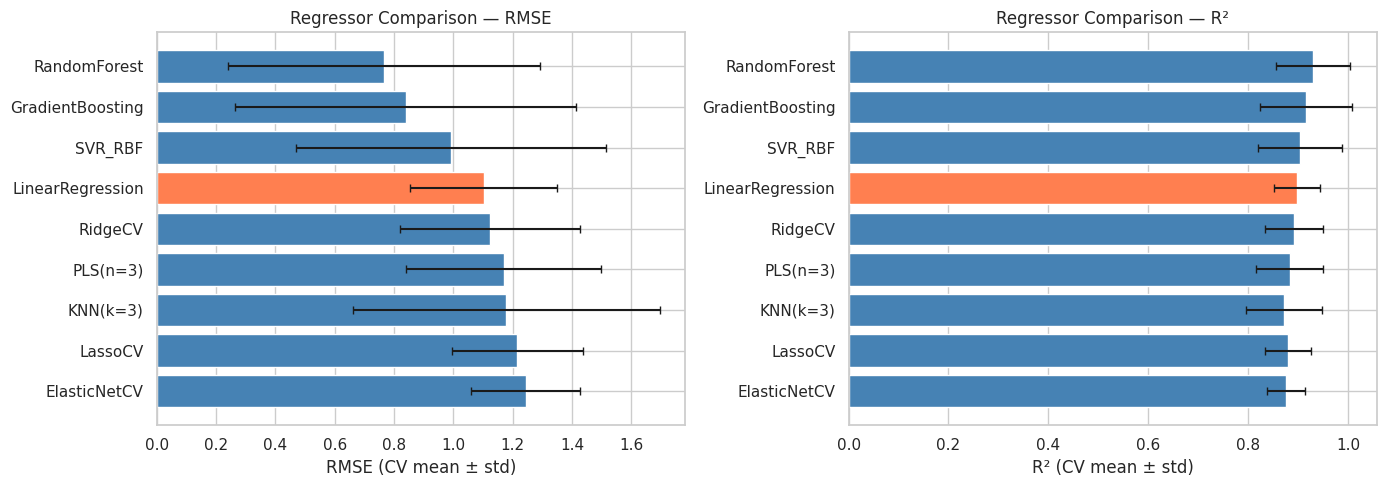

In [ ]:
def get_regressor_candidates() -> Dict[str, Any]:
    """รายการ regressor สำหรับเปรียบเทียบ."""
    return {
        "LinearRegression": LinearRegression(),
        "RidgeCV": RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5),
        "LassoCV": LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=10000),
        "ElasticNetCV": ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], cv=5, random_state=RANDOM_STATE, max_iter=10000),
        "PLS(n=3)": PLSRegression(n_components=3),
        "SVR_RBF": SVR(kernel="rbf", C=10, epsilon=0.1),
        "KNN(k=3)": KNeighborsRegressor(n_neighbors=3),
        "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=4, random_state=RANDOM_STATE),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE),
    }


def compare_regressors(
    X: pd.DataFrame,
    y: pd.Series,
    groups: np.ndarray,
) -> pd.DataFrame:
    """รัน CV ทุก regressor แล้วสร้าง leaderboard."""
    results = []
    for name, model in get_regressor_candidates().items():
        try:
            res = evaluate_model(model, X, y, groups, name)
            fm = res["fold_metrics"]
            results.append({
                "model": name,
                "rmse_mean": fm["rmse_mean"],
                "rmse_std": fm["rmse_std"],
                "mae_mean": fm["mae_mean"],
                "r2_mean": fm["r2_mean"],
                "r2_std": fm["r2_std"],
            })
            print(f"{name:20s}  RMSE={fm['rmse_mean']:.4f}  R²={fm['r2_mean']:.4f}")
        except Exception as exc:
            print(f"{name:20s}  ERROR: {exc}")

    leaderboard = pd.DataFrame(results).sort_values("rmse_mean")
    return leaderboard


leaderboard = compare_regressors(X_sel, y, groups)
print("\n=== Leaderboard (เรียงตาม RMSE) ===")
display(leaderboard)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = ["steelblue" if m != "LinearRegression" else "coral" for m in leaderboard["model"]]
ax.barh(leaderboard["model"], leaderboard["rmse_mean"], xerr=leaderboard["rmse_std"], color=colors, capsize=3)
ax.set_xlabel("RMSE (CV mean ± std)")
ax.set_title("Regressor Comparison — RMSE")
ax.invert_yaxis()

ax = axes[1]
ax.barh(leaderboard["model"], leaderboard["r2_mean"], xerr=leaderboard["r2_std"], color=colors, capsize=3)
ax.set_xlabel("R² (CV mean ± std)")
ax.set_title("Regressor Comparison — R²")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### ข้อเสนอแนะการเลือก Regressor

**สำหรับข้อมูล eNose ขนาดเล็ก (36–60 runs):**

1. **เริ่มจาก Linear Regression** — interpretable, เห็น coefficient ของแต่ละเซ็นเซอร์
2. **ถ้า overfit → Ridge/ElasticNet** — กัน multicollinearity ระหว่าง dV/dVmax/slope ของเซ็นเซอร์เดียวกัน
3. **ถ้าเซ็นเซอร์ correlated สูง → PLS** — ลดมิติก่อน regression
4. **Random Forest / GBM** — ใช้ดู feature importance แต่ระวัง overfit กับข้อมูลน้อย
5. **SVR/KNN** — ทดลองได้ แต่ไม่แนะนำเป็นโมเดลหลักเพราะตีความยาก

**อนาคต:**
- เพิ่ม repeat เป็น 5+ ต่อเงื่อนไข → ลด variance ของ CV
- ลอง log-transform target (`log(ppm)`) ถ้าความสัมพันธ์เป็น exponential
- Validate ข้ามอุณหภูมิ: train ที่ 30+40°C → test ที่ 50°C
- เพิ่ม interaction features: `dV_ss1 * temp_set`

## 7. บันทึกโมเดล + Inference

In [ ]:
# บันทึกโมเดล, scaler, feature list, metrics
model_bundle = {
    "pipeline": final_pipe,
    "selected_features": selected_features,
    "all_model_features": MODEL_FEATURES,
    "analysis_windows": ANALYSIS_WINDOWS,
    "include_bme": INCLUDE_BME,
    "include_temp_set": INCLUDE_TEMP_SET,
    "metrics": {
        "cv": linreg_result["fold_metrics"],
        "oof": linreg_result["oof_metrics"],
    },
    "leaderboard": leaderboard.to_dict(orient="records"),
    "feature_summary": feature_summary.to_dict(orient="records"),
}

model_path = OUTPUT_DIR / "methane_linreg_model.joblib"
joblib.dump(model_bundle, model_path)
print(f"บันทึกโมเดล → {model_path}")

# บันทึก metrics เป็น JSON
metrics_path = OUTPUT_DIR / "methane_linreg_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(model_bundle["metrics"], f, indent=2, ensure_ascii=False)
print(f"บันทึก metrics → {metrics_path}")

บันทึกโมเดล → /content/drive/MyDrive/eNose/models/methane_linreg_model.joblib
บันทึก metrics → /content/drive/MyDrive/eNose/models/methane_linreg_metrics.json


In [ ]:
def predict_run(
    folder_path: str,
    model_bundle: Optional[Dict] = None,
    adc_csv: Optional[str] = None,
    bme_csv: Optional[str] = None,
) -> Dict[str, Any]:
    """ทำนาย ppm จากโฟลเดอร์ หรือระบุไฟล์ adc/bme โดยตรง.

    Parameters
    ----------
    folder_path : str
        path โฟลเดอร์ที่มี adc1263_*.csv / bme280_*.csv
        ใช้สำหรับ parse ชื่อ (temp_set, ppm) เสมอ
    model_bundle : dict, optional
        ถ้าไม่ระบุ จะโหลดจาก model_path
    adc_csv : str, optional
        path ไฟล์ adc โดยตรง — ถ้าไม่ระบุ จะเลือกไฟล์ล่าสุดในโฟลเดอร์
    bme_csv : str, optional
        path ไฟล์ bme โดยตรง — ถ้าไม่ระบุ จะจับคู่จาก timestamp

    Returns
    -------
    dict: predicted_ppm, actual_ppm, temp_set, adc_file, bme_file, qc_pass, features
    """
    if model_bundle is None:
        model_bundle = joblib.load(model_path)

    folder = Path(folder_path)

    # ── เลือกไฟล์ ──────────────────────────────────────────────────────────
    if adc_csv is not None:
        adc_file = Path(adc_csv)
        bme_file = Path(bme_csv) if bme_csv else _match_bme(
            adc_file, sorted(folder.glob("bme280_*.csv"))
        )
    else:
        adc_file = _latest_file(folder, "adc1263")
        bme_file = _latest_file(folder, "bme280")

    if adc_file is None or not adc_file.exists():
        raise FileNotFoundError(f"ไม่พบไฟล์ adc: {adc_file}")

    # ── Extract + predict ───────────────────────────────────────────────────
    meta = parse_folder_meta(folder.name)
    meta.update({"folder": folder.name, "repeat": None, "group_id": None})

    row = extract_run(str(adc_file), str(bme_file) if bme_file and bme_file.exists() else None, meta)

    selected = model_bundle["selected_features"]
    pipe = model_bundle["pipeline"]
    predicted_ppm = predict_ppm_pi_style(row, selected, pipe)

    return {
        "folder": folder.name,
        "adc_file": adc_file.name,
        "bme_file": bme_file.name if bme_file and bme_file.exists() else None,
        "predicted_ppm": predicted_ppm,
        "actual_ppm": meta.get("methane_ppm"),
        "temp_set": meta.get("temp_set"),
        "qc_pass": row.get("qc_pass", False),
        "features": feat_row,
    }


# ── ตัวอย่างการใช้งาน ────────────────────────────────────────────────────────

# แบบที่ 1: ใช้ไฟล์ล่าสุดในโฟลเดอร์ (เหมือนเดิม)
if len(manifest) > 0:
    test_folder = manifest.iloc[0]["folder_path"]
    result = predict_run(test_folder, model_bundle)
    print("── แบบที่ 1: ไฟล์ล่าสุด ──")
    print(f"File:        {result['adc_file']}")
    print(f"Predicted:   {result['predicted_ppm']:.3f} ppm" if result['predicted_ppm'] is not None else "Predicted:   (ไม่ทำนาย — feature ไม่ครบ)")
    print(f"Actual:      {result['actual_ppm']} ppm")
    print(f"temp_set:    {result['temp_set']}°C")
    print(f"QC pass:     {result['qc_pass']}")

# แบบที่ 2: เลือกไฟล์เองโดยตรง
# result2 = predict_run(
#     folder_path = "/content/drive/MyDrive/eNose/testdata/50_5ppm_28.5",
#     model_bundle = model_bundle,
#     adc_csv = "/content/drive/MyDrive/eNose/testdata/50_5ppm_28.5/adc1263_20260528_114945.csv",
#     bme_csv = "/content/drive/MyDrive/eNose/testdata/50_5ppm_28.5/bme280_20260528_114945.csv",
# )
# print(result2)

# แบบที่ 3: ทดสอบทุก run ใน manifest
# results = []
# for _, row in manifest.iterrows():
#     r = predict_run(
#         folder_path = row["folder_path"],
#         model_bundle = model_bundle,
#         adc_csv = row["adc_csv"],
#         bme_csv = row["bme_csv"],
#     )
#     r["error"] = abs(r["predicted_ppm"] - r["actual_ppm"])
#     results.append(r)
# display(pd.DataFrame(results)[["folder", "adc_file", "actual_ppm", "predicted_ppm", "error", "qc_pass"]])

── แบบที่ 1: ไฟล์ล่าสุด ──
File:        adc1263_20260528_181934.csv
Predicted:   0.401 ppm
Actual:      1.0 ppm
temp_set:    30°C
QC pass:     True


## สรุปและ Next Steps

### สิ่งที่ notebook นี้ทำ
1. โหลดข้อมูลจาก Google Drive (โครงสร้าง `testdata/`)
2. Extract 25 features (ΔV, dVmax, slope, ratio, hybrid, BME) ตาม convention eNose
3. Feature selection ด้วย correlation top-k กับ ppm
4. Train Linear Regression + GroupKFold CV
5. เปรียบเทียบ 9 regressors
6. บันทึกโมเดล + ฟังก์ชัน inference

### ข้อจำกัด
- ข้อมูลเล็ก (~36–60 runs) → CV variance สูง, อย่า over-interpret R²
- BME features อาจเป็น confounder ถ้าเก็บข้อมูลคนละวัน/สภาพอากาศ

### แนะนำขั้นตอนถัดไป
1. **เพิ่ม repeat** เป็น 5+ ต่อ `(temp, ppm)` เพื่อลด variance
2. **ลอง log-target**: `y = log(ppm + ε)` ถ้าความสัมพันธ์ไม่เป็นเส้นตรง
3. **Cross-temperature validation**: train 30+40°C → test 50°C (ดู generalization)
4. **Interaction features**: `dV_ss1 × temp_set`, `dVmax_ss2 / T_measure`
5. **Deploy บน Pi**: export coefficients เป็น JSON → ใช้ใน `pull_feature/` pipeline
6. **เปรียบเทียบกับโมเดลเดิม** ใน `BuildML_PC/train/models/` (ถ้ามี)

## 8. ทดสอบกับไฟล์ใหม่ (Test on unseen run)

อัปโหลดไฟล์ `adc1263_*.csv` และ `bme280_*.csv` จากโฟลเดอร์ `acquisition/processed_data/`  
แล้วรัน predict เพื่อดูว่าโมเดลทำนาย ppm ได้เท่าไหร่

> **หมายเหตุ:** ไฟล์ในโฟลเดอร์ `processed_data/` ไม่มี label ppm — ผล `actual_ppm` จะแสดงเป็น `None`  
> ถ้าต้องการเปรียบเทียบกับค่าจริง ให้กรอก `KNOWN_PPM` ด้านล่าง

## 9. ทดสอบจาก Google Drive Path + Waveform Visualization

ใช้เมื่อไฟล์อยู่บน Google Drive แล้ว (**ไม่ต้องอัปโหลดซ้ำ**) และต้องการดูกราฟ waveform
พร้อม analysis window ที่ใช้สกัด feature

ไฟล์ตัวอย่าง: `acquisition/processed_data/adc1263_20260608_172012.csv`

**สิ่งที่แสดง:**
- ค่า PPM ที่ทำนาย vs ค่าจริงที่รู้
- ตาราง feature ทั้งหมดที่สกัดได้ (ΔV, dVmax, slope, ratio, hybrid, BME) — highlight feature ที่ใช้ใน model
- กราฟ waveform ss1–ss4 พร้อม baseline/measure window
- % relative error

ใช้ model_bundle ที่อยู่ใน memory
Features ในโมเดล: ['dV_ss4', 'dV_ss3', 'T_baseline', 'T_measure']
Analysis windows: {'baseline': (250, 300), 'measure': (305, 365)}

ADC rows: 60596  |  elapsed max: 606.0 s
BME rows: 4674  |  T_measure avg: 37.16 C

=== Features ที่สกัดได้ (สีฟ้า = ใช้ใน model) ===


,value,in_model
dV_ss1,-0.008905,False
dV_ss2,-0.009633,False
dV_ss3,0.007981,True
dV_ss4,0.011077,True
dVmax_ss1,0.002568,False
dVmax_ss2,0.003009,False
dVmax_ss3,0.017500,False
dVmax_ss4,0.020146,False
slope_ss1,-0.000192,False
slope_ss2,-0.000213,False



  Actual PPM      : 10.00 ppm
  Predicted PPM   : 9.1950 ppm
  Error           : -0.8050 ppm
  |Error|         : 0.8050 ppm
  Relative error  : 8.1%
  Training CV MAE : 0.8571 ppm
  ผล              : ภายใน training error


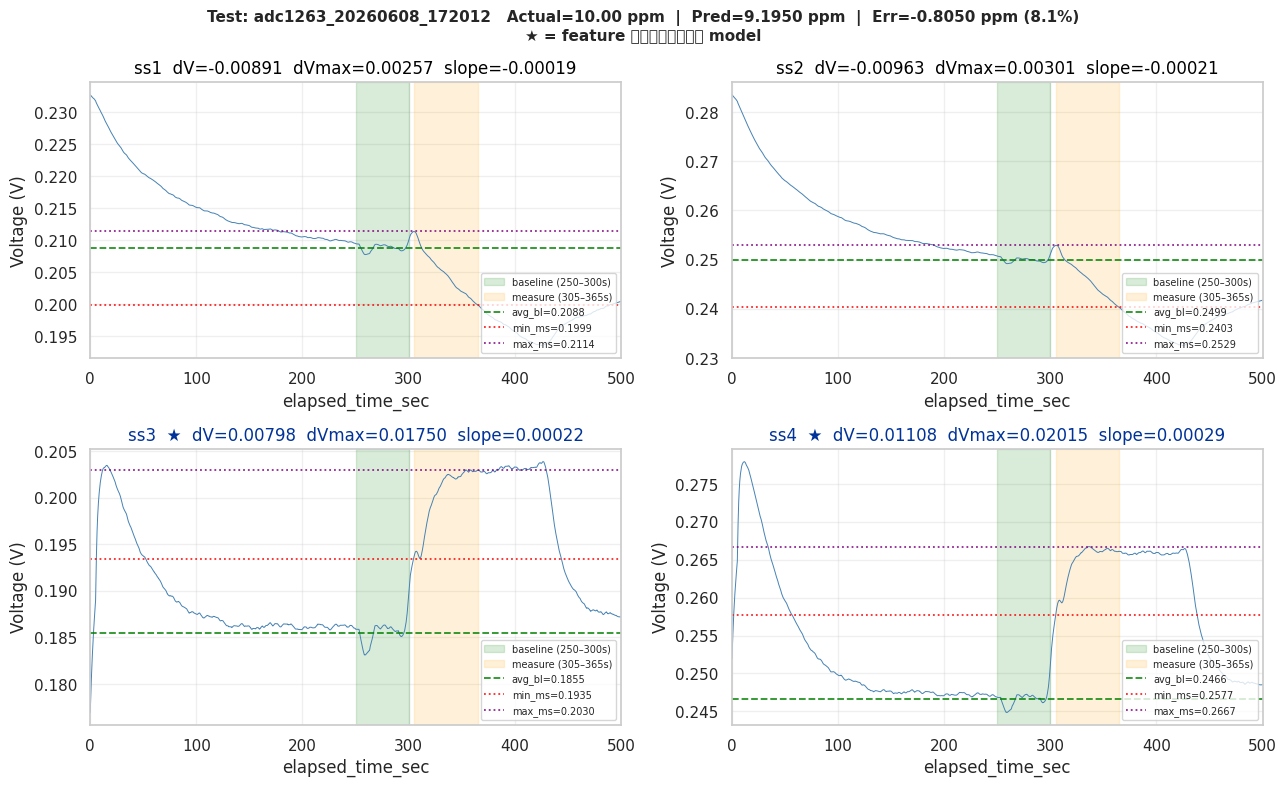

In [ ]:
# @title ทดสอบจาก Google Drive path + Waveform
# ─────────────────────────────────────────────────────────────────────────────
# แก้ 3 บรรทัดนี้เท่านั้น
# ─────────────────────────────────────────────────────────────────────────────
TEST_ADC_PATH = "/content/drive/Othercomputers/My Laptop/coding project/eNose/eNose_methane/test record/process/testing 09.06.2026/11.30/adc1263_20260609_112521.csv"
TEST_BME_PATH = "/content/drive/Othercomputers/My Laptop/coding project/eNose/eNose_methane/test record/process/testing 09.06.2026/11.30/bme280_20260609_112520.csv" # Assuming BME was not successfully uploaded or has no relevant data
ACTUAL_PPM    = 5.0   # ← ใส่ค่า ppm จริงที่รู้
# ─────────────────────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings("ignore")

# ── โหลด model bundle (ถ้ายังไม่มีใน memory) ────────────────────────────────
if "model_bundle" not in dir() or model_bundle is None:
    model_path = OUTPUT_DIR / "methane_linreg_model.joblib"
    model_bundle = joblib.load(model_path)
    print(f"โหลดโมเดลจาก: {model_path}")
else:
    print("ใช้ model_bundle ที่อยู่ใน memory")

selected_feats = model_bundle["selected_features"]
analysis_wins  = model_bundle["analysis_windows"]
pipe_loaded    = model_bundle["pipeline"]
print(f"Features ในโมเดล: {selected_feats}")
print(f"Analysis windows: {analysis_wins}")

# ── อ่านไฟล์ ───────────────────────────────────────────────────────────────
adc_df = pd.read_csv(TEST_ADC_PATH)
bme_df = pd.read_csv(TEST_BME_PATH) if TEST_BME_PATH else None
print(f"\nADC rows: {len(adc_df)}  |  elapsed max: {adc_df['elapsed_time_sec'].max():.1f} s")
if bme_df is not None:
    print(f"BME rows: {len(bme_df)}  |  T_measure avg: {bme_df['temperature_c_lp_ma'].mean():.2f} C")

# ── สกัด feature ───────────────────────────────────────────────────────────
meta_test = {
    "folder":      "processed_data",
    "temp_set":    None,
    "methane_ppm": ACTUAL_PPM,
    "repeat":      1,
    "group_id":    0,
}
feat_row = extract_run(
    TEST_ADC_PATH,
    TEST_BME_PATH if TEST_BME_PATH else None,
    meta_test,
)

# ── ตาราง feature ──────────────────────────────────────────────────────────
display_cols = list(ALL_EXTRACTED_FEATURES)
if "temp_set" in model_bundle.get("all_model_features", []):
    display_cols.append("temp_set")

feat_display = {col: feat_row.get(col, np.nan) for col in display_cols}
feat_df = pd.DataFrame([feat_display]).T.rename(columns={0: "value"})
feat_df["group"] = [get_feature_group(f) for f in feat_df.index]
feat_df["in_model"] = feat_df.index.isin(selected_feats)
feat_df["value"] = feat_df["value"].round(6)

# เรียงตามกลุ่ม feature เพื่อให้อ่านง่าย
group_order = list(FEATURE_GROUPS.keys()) + ["meta", "other"]
feat_df = feat_df.reset_index(names="feature")
feat_df["group_order"] = feat_df["group"].map({g: i for i, g in enumerate(group_order)})
feat_df = feat_df.sort_values(["group_order", "feature"]).drop(columns=["group_order"]).set_index("feature")

print("\n=== Features ที่สกัดได้ (สีฟ้า = ใช้ใน model) ===")
display(
    feat_df.style.apply(
        lambda row: ["background-color: #cce5ff" if row["in_model"] else "" for _ in row],
        axis=1,
    )
)

# สรุปเฉพาะกลุ่ม sensor ใหม่ (ratio / hybrid)
for grp in ["ratio", "hybrid"]:
    cols = [c for c in display_cols if c in FEATURE_GROUPS[grp]]
    if cols:
        print(f"\n=== {grp} features ===")
        display(feat_df.loc[cols])

# ── Predict (logic เดียวกับ predict_methane.py บน Pi) ───────────────────────
pred_ppm = predict_ppm_pi_style(feat_row, selected_feats, pipe_loaded)

print("\n" + "=" * 50)
print(f"  Actual PPM      : {ACTUAL_PPM:.2f} ppm")
if pred_ppm is None:
    print("  Predicted PPM   : (ไม่ทำนาย — feature ไม่ครบ, เหมือน GUI บน Pi)")
    error_ppm = abs_err = rel_err_pct = float("nan")
else:
    print(f"  Predicted PPM   : {pred_ppm:.4f} ppm")
    error_ppm   = pred_ppm - ACTUAL_PPM
    abs_err     = abs(error_ppm)
    rel_err_pct = abs_err / ACTUAL_PPM * 100
    print(f"  Error           : {error_ppm:+.4f} ppm")
    print(f"  |Error|         : {abs_err:.4f} ppm")
    print(f"  Relative error  : {rel_err_pct:.1f}%")
print("=" * 50)

train_mae = model_bundle["metrics"]["oof"].get("mae", None)
if train_mae and pred_ppm is not None:
    print(f"  Training CV MAE : {train_mae:.4f} ppm")
    verdict = "ภายใน training error" if abs_err <= train_mae * 1.5 else "สูงกว่า training error"
    print(f"  ผล              : {verdict}")

# ── Waveform + analysis window ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()
bl_lo, bl_hi = analysis_wins["baseline"]
ms_lo, ms_hi = analysis_wins["measure"]

for ax, sensor in zip(axes, SENSORS):
    col = f"{sensor}_lp_ma"
    if col not in adc_df.columns:
        ax.set_visible(False)
        continue
    t = adc_df["elapsed_time_sec"]
    v = adc_df[col]

    ax.plot(t, v, linewidth=0.7, color="steelblue")
    ax.axvspan(bl_lo, bl_hi, alpha=0.15, color="green",  label=f"baseline ({bl_lo:.0f}–{bl_hi:.0f}s)")
    ax.axvspan(ms_lo, ms_hi, alpha=0.15, color="orange", label=f"measure ({ms_lo:.0f}–{ms_hi:.0f}s)")

    bl_slice = adc_df.loc[(t >= bl_lo) & (t <= bl_hi), col]
    ms_slice = adc_df.loc[(t >= ms_lo) & (t <= ms_hi), col]
    if len(bl_slice) > 0 and len(ms_slice) > 0:
        avg_bl = float(bl_slice.mean())
        min_ms = float(ms_slice.min())
        max_ms = float(ms_slice.max())
        ax.axhline(avg_bl, color="green",  ls="--", lw=1.3, alpha=0.85, label=f"avg_bl={avg_bl:.4f}")
        ax.axhline(min_ms, color="red",    ls=":",  lw=1.3, alpha=0.85, label=f"min_ms={min_ms:.4f}")
        ax.axhline(max_ms, color="purple", ls=":",  lw=1.3, alpha=0.85, label=f"max_ms={max_ms:.4f}")

    dv     = feat_row.get(f"dV_{sensor}",     np.nan)
    dvmax  = feat_row.get(f"dVmax_{sensor}",  np.nan)
    slp    = feat_row.get(f"slope_{sensor}",  np.nan)
    ratio  = feat_row.get(f"ratio_{sensor}",  np.nan)
    hybrid = feat_row.get(f"hybrid_{sensor}", np.nan)
    sensor_feats = [f"dV_{sensor}", f"dVmax_{sensor}", f"slope_{sensor}", f"ratio_{sensor}", f"hybrid_{sensor}"]
    in_m = any(f in selected_feats for f in sensor_feats)
    title_color = "#003399" if in_m else "black"

    ax.set_title(
        f"{sensor}{'  ★' if in_m else ''}\n"
        f"dV={dv:.5f}  dVmax={dvmax:.5f}  slope={slp:.5f}\n"
        f"ratio={ratio:.5f}  hybrid={hybrid:.5f}",
        color=title_color,
        fontsize=9,
    )
    ax.set_xlabel("elapsed_time_sec")
    ax.set_ylabel("Voltage (V)")
    ax.legend(fontsize=7, loc="lower right")
    ax.set_xlim([0, min(500, float(t.max()))])
    ax.grid(True, alpha=0.3)

pred_label = f"{pred_ppm:.4f}" if pred_ppm is not None else "N/A"
err_label = f"{error_ppm:+.4f} ({rel_err_pct:.1f}%)" if pred_ppm is not None else "N/A"
fig.suptitle(
    f"Test: adc1263_20260608_172012   "
    f"Actual={ACTUAL_PPM:.2f} ppm  |  Pred={pred_label} ppm  |  "
    f"Err={err_label}\n"
    f"★ = feature ที่ใช้ใน model",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()

if not feat_row.get("qc_pass", True):
    print(f"\n⚠ QC: {feat_row.get('qc_notes', 'unknown')}")
    print("ผลการทำนายอาจไม่น่าเชื่อถือ")